In [4]:
from google.colab import files
files.upload()

Saving cardekho_dataset.csv to cardekho_dataset.csv


{'cardekho_dataset.csv': b',car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price\n0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000\n1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9,1197,82,5,550000\n2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17,1197,80,5,215000\n3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.1,5,226000\n4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000\n5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.9,998,67.1,5,350000\n6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.9,5,315000\n7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000\n8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000\n12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.6,1197,85,

## Preprocess Data

### Subtask:
Clean and preprocess the loaded data. This typically includes handling missing values, encoding categorical features, and potentially scaling numerical features.

In [5]:
import pandas as pd

# Display basic information about the DataFrame
df = pd.read_csv('cardekho_dataset.csv')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


None

From the `df.info()` output, we can observe the data types and potential missing values. Let's inspect the first few rows and check for explicit missing values.

In [6]:
# Display the first few rows of the DataFrame
display(df.head())

# Check for missing values
display(df.isnull().sum())

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


Based on the `isnull().sum()` output, there are no missing values in this dataset. However, we should clean the `car_name` column to extract the brand and model properly. Also, let's process the `engine`, `max_power`, and `mileage` columns to ensure they are numeric and handle their units. The `vehicle_age` is already a numerical representation of the car's age.

In [11]:
# The 'engine', 'max_power', and 'mileage' columns are already numeric (int64, float64).
# So, string replacement operations are not needed for these columns.
# This cell was intended to clean units, but the data is already clean in these columns.

# Display cleaned data types and head
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


None

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [12]:
# The 'brand' and 'model' columns already exist in the dataset, which simplifies things.
# Let's verify their unique values and ensure they are clean.

# Display unique brands
print('Unique Brands:')
display(df['brand'].nunique())
display(df['brand'].unique())

# Display unique models
print('\nUnique Models:')
display(df['model'].nunique())
display(df['model'].unique())

Unique Brands:


32

array(['Maruti', 'Hyundai', 'Ford', 'Renault', 'Mini', 'Mercedes-Benz',
       'Toyota', 'Volkswagen', 'Honda', 'Mahindra', 'Datsun', 'Tata',
       'Kia', 'BMW', 'Audi', 'Land Rover', 'Jaguar', 'MG', 'Isuzu',
       'Porsche', 'Skoda', 'Volvo', 'Lexus', 'Jeep', 'Maserati',
       'Bentley', 'Nissan', 'ISUZU', 'Ferrari', 'Mercedes-AMG',
       'Rolls-Royce', 'Force'], dtype=object)


Unique Models:


120

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

The `brand` and `model` columns appear to be already well-separated from the `car_name` column. This means we don't need to perform string extraction from `car_name` to create these columns.

However, the `Unnamed: 0` column is an index column and is not useful for the model. We can drop it. After that, let's look at the distribution of some numerical features like `selling_price` and `km_driven` and categorical features like `fuel_type` and `transmission_type`.

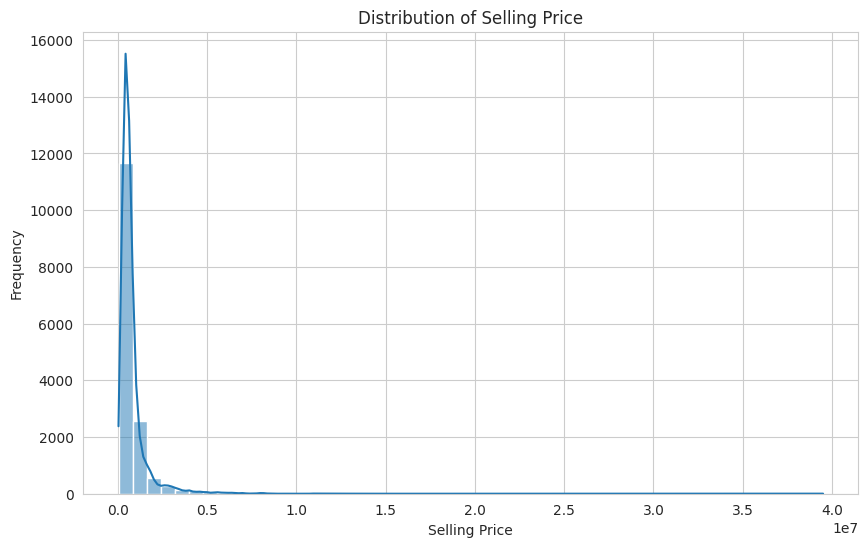

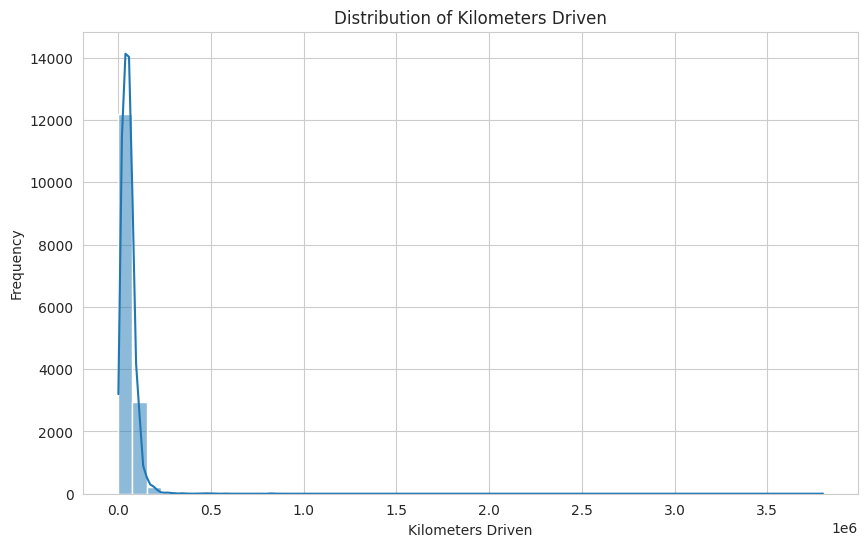

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Plot distribution of 'selling_price'
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of 'km_driven'
plt.figure(figsize=(10, 6))
sns.histplot(df['km_driven'], bins=50, kde=True)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Frequency')
plt.show()

### Handling Categorical Features

We need to convert categorical variables into a numerical format using techniques like one-hot encoding so that machine learning models can process them. Columns such as `seller_type`, `fuel_type`, and `transmission_type` are good candidates for this transformation.

In [16]:
# Select categorical columns for one-hot encoding
categorical_cols = ['seller_type', 'fuel_type', 'transmission_type']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the DataFrame with encoded features
display(df_encoded.head())

# Display the info of the new DataFrame to see the updated columns and data types
display(df_encoded.info())

,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,True,False,False,False,False,True,True
1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,True,False,False,False,False,True,True
2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,True,False,False,False,False,True,True
3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,True,False,False,False,False,True,True
4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,False,False,True,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_name                      15411 non-null  object 
 1   brand                         15411 non-null  object 
 2   model                         15411 non-null  object 
 3   vehicle_age                   15411 non-null  int64  
 4   km_driven                     15411 non-null  int64  
 5   mileage                       15411 non-null  float64
 6   engine                        15411 non-null  int64  
 7   max_power                     15411 non-null  float64
 8   seats                         15411 non-null  int64  
 9   selling_price                 15411 non-null  int64  
 10  seller_type_Individual        15411 non-null  bool   
 11  seller_type_Trustmark Dealer  15411 non-null  bool   
 12  fuel_type_Diesel              15411 non-null  bool   
 13  f

None

### Splitting Data into Training and Testing Sets

Before building a machine learning model, it's essential to split the data into training and testing sets. The training set will be used to train the model, and the testing set will be used to evaluate its performance on unseen data. We'll define `selling_price` as our target variable (y) and all other relevant numerical and one-hot encoded columns as features (X).

In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(['selling_price', 'car_name', 'brand', 'model'], axis=1)
y = df_encoded['selling_price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

display(X_train.head())

Shape of X_train: (12328, 13)
Shape of X_test: (3083, 13)
Shape of y_train: (12328,)
Shape of y_test: (3083,)


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,7,70252,11.20,2400,215.0,5,False,False,True,False,False,False,False
1347,2,10000,23.84,1199,84.0,5,True,False,False,False,False,True,True
10363,2,6000,19.00,1950,241.3,5,False,False,True,False,False,False,False
316,7,63000,17.80,1497,117.3,5,False,False,False,False,False,True,True
10638,10,80292,20.36,1197,78.9,5,False,False,False,False,False,True,True


### Model Training: LightGBM Regressor

We will use LightGBM, a gradient boosting framework, due to its efficiency and good performance for tabular data. We'll train a `LGBMRegressor` on our prepared training data.

In [18]:
import lightgbm as lgb

# Initialize the LightGBM Regressor model
# You can fine-tune hyperparameters later for better performance
lgbm = lgb.LGBMRegressor(random_state=42)

# Train the model on the training data
lgbm.fit(X_train, y_train)

print("LightGBM Regressor model trained successfully!")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 850
[LightGBM] [Info] Number of data points in the train set: 12328, number of used features: 12
[LightGBM] [Info] Start training from score 772120.619727
LightGBM Regressor model trained successfully!


### Model Evaluation: MAE, MSE, and R-squared

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = lgbm.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Often reported with MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 108203.26
Mean Squared Error (MSE): 54083304634.89
Root Mean Squared Error (RMSE): 232558.17
R-squared (R2): 0.93


### Visualize Predictions vs. Actual Values

To further understand the model's performance, let's visualize the actual selling prices against the predicted selling prices.

### Saving the Trained Model

Once satisfied with the model's performance, it's good practice to save the trained model to disk. This allows you to reload it later for making new predictions without needing to retrain it. We'll use the `joblib` library, which is efficient for saving large NumPy arrays, making it suitable for scikit-learn and LightGBM models.

In [22]:
import joblib
import os

# Define a filename for your model
model_filename = 'lgbm_car_price_predictor.joblib'

# Save the model to disk
joblib.dump(lgbm, model_filename)

print(f"Model saved successfully to {model_filename}")
print(f"File size: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

Model saved successfully to lgbm_car_price_predictor.joblib
File size: 0.27 MB


### Loading the Saved Model (Demonstration)

To confirm the model was saved correctly, you can load it back into memory and verify its type. This cell is just for demonstration; you wouldn't typically load it immediately after saving in the same session, but it shows how it's done.

In [23]:
# Load the model from disk
loaded_lgbm = joblib.load(model_filename)

print(f"Model loaded successfully. Type: {type(loaded_lgbm)}")

# You can now use 'loaded_lgbm' to make new predictions, for example:
# new_predictions = loaded_lgbm.predict(X_new)


Model loaded successfully. Type: <class 'lightgbm.sklearn.LGBMRegressor'>


### Making a Prediction with the Loaded Model

To make a prediction for a new car, you'll need to create a pandas DataFrame that mimics the structure of your `X_train` data (i.e., the same columns in the same order, with numerical and one-hot encoded features). Let's create a sample input for a hypothetical new car and get a prediction.

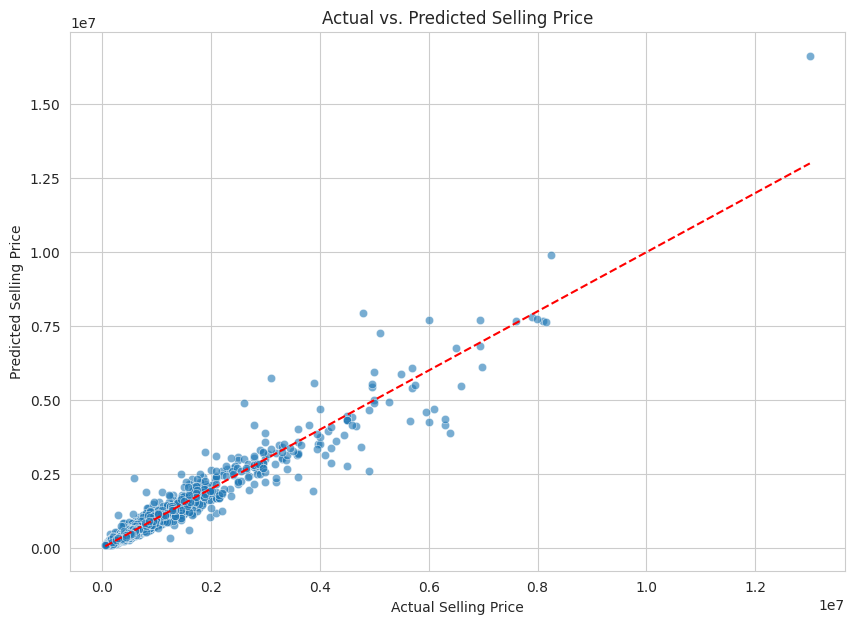

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.title('Actual vs. Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.show()

### Feature Importance

Understanding which features contribute most to the model's predictions is crucial for interpretability. We can extract feature importances from our trained LightGBM model.

,Feature,Importance
4,max_power,851
2,mileage,641
3,engine,461
1,km_driven,410
0,vehicle_age,391
5,seats,114
12,transmission_type_Manual,46
11,fuel_type_Petrol,31
8,fuel_type_Diesel,28
6,seller_type_Individual,27


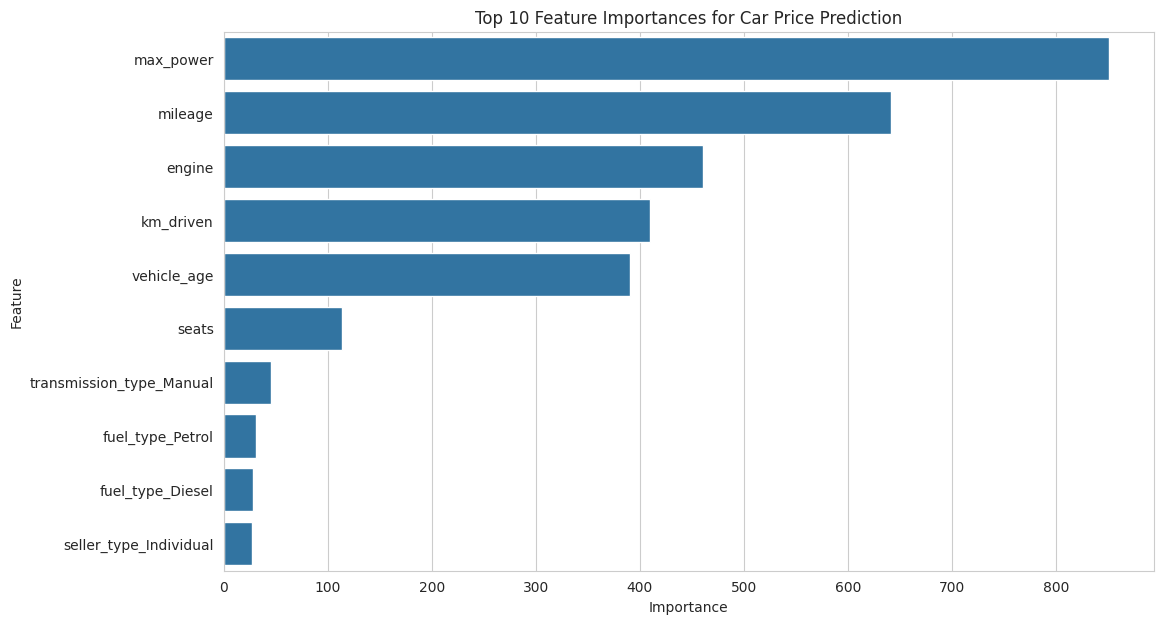

In [21]:
# Get feature importances from the trained LightGBM model
feature_importances = lgbm.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top N most important features
display(features_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10))
plt.title('Top 10 Feature Importances for Car Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [24]:
# Create a sample new car data point (ensure column order and types match X_train)
# This is just an example, replace with actual new car data if available
# The columns should be: 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
# 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel',
# 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual'

sample_new_car = pd.DataFrame([[5, 50000, 18.0, 1200, 80.0, 5, 0, 1, 0, 0, 0, 1, 1]],
                              columns=X_train.columns)

display(sample_new_car)

# Make a prediction using the loaded model
predicted_price = loaded_lgbm.predict(sample_new_car)

print(f"Predicted selling price for the new car: ₹{predicted_price[0]:,.2f}")

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,5,50000,18.0,1200,80.0,5,0,1,0,0,0,1,1


Predicted selling price for the new car: ₹495,537.06
